In [1]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline     
sns.set(color_codes=True)
# pip install pandas openpyxl

c:\Users\huang\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Load in Data from CSV

In [2]:
df = pd.read_csv("./UN_Tourism_cleared.csv")
# To display the top 5 rows 
df.head(5)
df.tail(5)                        # To display the botton 5 rows

,indicator_code,indicator_label,reporter_area_code,reporter_area_label,year,value,unit,notes,source,Unnamed: 9,...,Unnamed: 31,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40
1766,ST_GDP_ZS,Tourism direct GDP as a proportion of total GD...,753,Eastern and South-Eastern Asia,2020,2.96220,PERCENT,UN Region,Aggregate,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1767,ST_GDP_ZS,Tourism direct GDP as a proportion of total GD...,753,Eastern and South-Eastern Asia,2021,2.84073,PERCENT,UN Region,Aggregate,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1768,ST_GDP_ZS,Tourism direct GDP as a proportion of total GD...,753,Eastern and South-Eastern Asia,2022,3.08092,PERCENT,UN Region,Aggregate,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1769,ST_GDP_ZS,Tourism direct GDP as a proportion of total GD...,753,Eastern and South-Eastern Asia,2023,3.83896,PERCENT,UN Region,Aggregate,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1770,ST_GDP_ZS,Tourism direct GDP as a proportion of total GD...,753,Eastern and South-Eastern Asia,2024,4.01696,PERCENT,UN Region,Aggregate,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Variable	Description
- indicator_code	Code that identifies the indicator.
- indicator_label	Description of the indicator.
- reporter_area_code	Code that identifies the geographic area represented by the statistical focal point that reported the data.
- reporter_area_label	Name of the reporter area as per the United Nations standard for statistical use (M49).
- year	Year represented by the value of the indicator.
- value	Value of the indicator.
- unit	Unit of measurement that defines the scale or type of the value.
- notes	Additional comments (if any)
- source	Name of the institution, organization, or official data source responsible for producing or providing the indicator data.

Check the types of data, Column uniques, nulls

In [3]:
df.dtypes
df.columns.tolist()
df['reporter_area_label'].unique()
df.isnull().sum()

indicator_code            0
indicator_label           0
reporter_area_code        0
reporter_area_label       0
year                      0
value                     0
unit                      0
notes                   593
source                    0
Unnamed: 9             1771
Unnamed: 10            1771
Unnamed: 11            1771
Unnamed: 12            1771
Unnamed: 13            1771
Unnamed: 14            1771
Unnamed: 15            1771
Unnamed: 16            1771
Unnamed: 17            1771
Unnamed: 18            1771
Unnamed: 19            1771
Unnamed: 20            1771
Unnamed: 21            1771
Unnamed: 22            1771
Unnamed: 23            1771
Unnamed: 24            1771
Unnamed: 25            1771
Unnamed: 26            1771
Unnamed: 27            1771
Unnamed: 28            1771
Unnamed: 29            1771
Unnamed: 30            1771
Unnamed: 31            1771
Unnamed: 32            1771
Unnamed: 33            1771
Unnamed: 34            1771
Unnamed: 35         

Remove un-needed columns and renaming

In [4]:
# Select only a few columns
new_df = df[['indicator_code','reporter_area_code' , 'reporter_area_label', 'year', 'value','source']]
# print(new_df.dtypes)
# print(new_df.head)
# print('_'*70)
# print(new_df.tail)
# print(df['partner_area_label'].unique())
# print(df['reporter_area_label'].unique())
# Filter for USA only and non-total
filtered_df = new_df[
    (new_df['reporter_area_code'] == 840) ] 
# filtered_df = filtered_df[
#     (filtered_df['partner_area_code'] != 999) ] 

print('~'*70)
# print(filtered_df['partner_area_code'].unique())

print(filtered_df.tail())
print(f"Shape: {filtered_df.shape}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
     indicator_code  reporter_area_code       reporter_area_label  year  \
1261      ST_GDP_ZS                 840  United States of America  2019   
1262      ST_GDP_ZS                 840  United States of America  2020   
1263      ST_GDP_ZS                 840  United States of America  2021   
1264      ST_GDP_ZS                 840  United States of America  2022   
1265      ST_GDP_ZS                 840  United States of America  2023   

        value                                             source  
1261  3.01889  US Department of Commerce, Bureau of Economic ...  
1262  2.14740  US Department of Commerce, Bureau of Economic ...  
1263  2.76457  US Department of Commerce, Bureau of Economic ...  
1264  2.96000  US Department of Commerce, Bureau of Economic ...  
1265  3.03000  US Department of Commerce, Bureau of Economic ...  
Shape: (16, 6)


Basic Bar chart

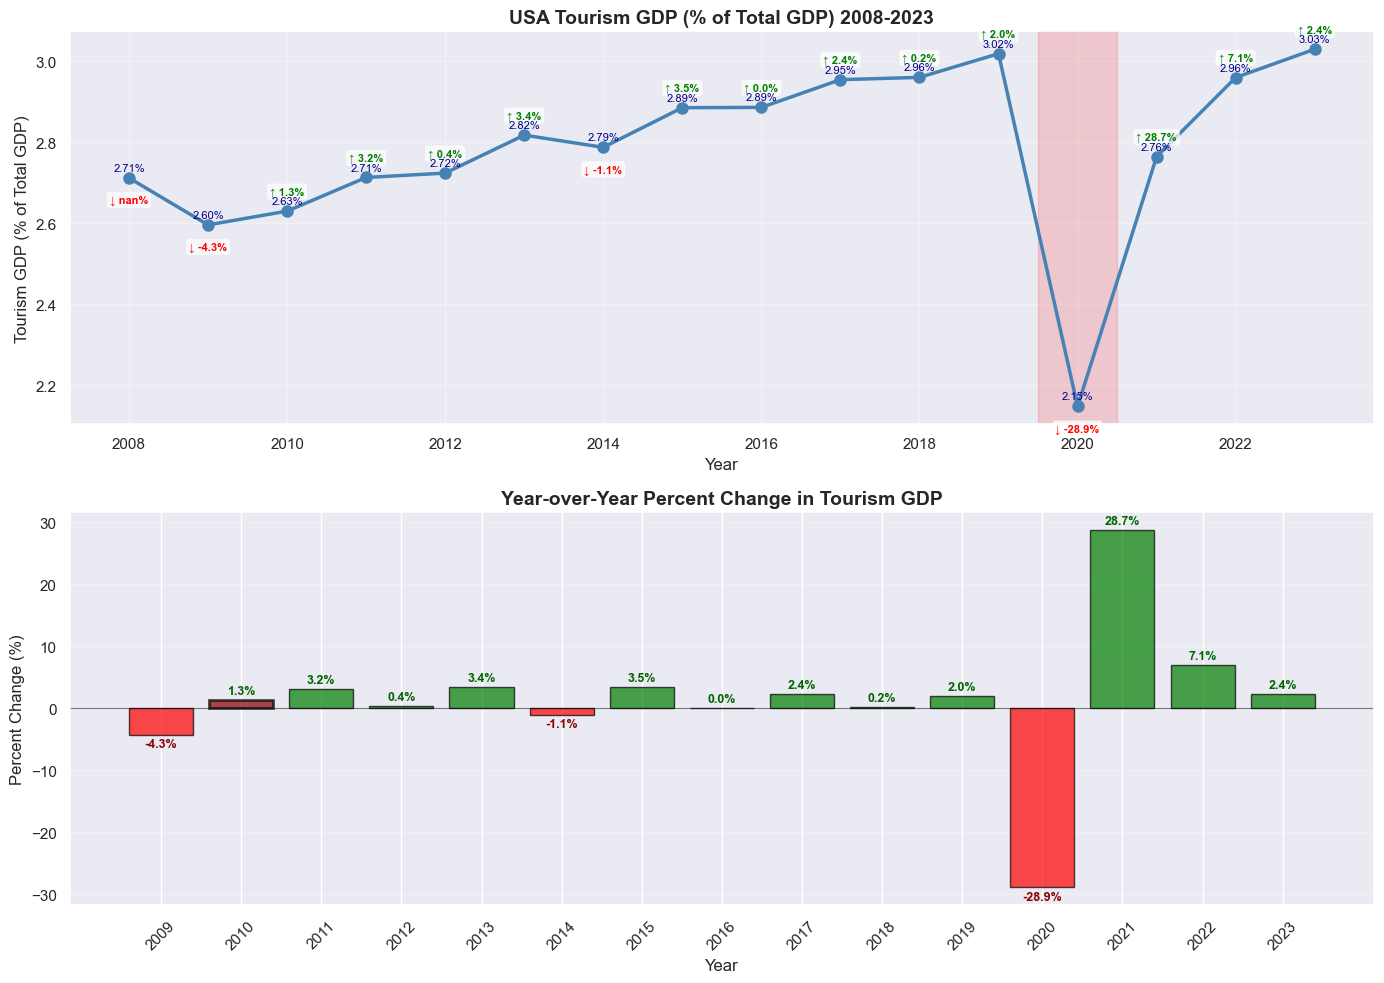

In [5]:

# Filter for USA data
filtered_df = new_df[new_df['reporter_area_label'] == 'United States of America'].copy()

# Sort by year
filtered_df = filtered_df.sort_values('year')

# Calculate year-over-year percent change
filtered_df['pct_change'] = filtered_df['value'].pct_change() * 100

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ===== SUBPLOT 1: Values with % Change Annotations =====
ax1.plot(filtered_df['year'], filtered_df['value'], 
         marker='o', linewidth=2.5, markersize=8, color='steelblue')
ax1.set_title('USA Tourism GDP (% of Total GDP) 2008-2023', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Tourism GDP (% of Total GDP)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Add % change annotations on the line
for i, row in filtered_df.iterrows():
    if i > 0:  # Skip first year
        color = 'green' if row['pct_change'] > 0 else 'red'
        arrow = '↑' if row['pct_change'] > 0 else '↓'
        ax1.annotate(f"{arrow} {row['pct_change']:.1f}%", 
                    (row['year'], row['value']),
                    textcoords="offset points", 
                    xytext=(0, 12 if row['pct_change'] > 0 else -18),
                    ha='center',
                    fontsize=8,
                    fontweight='bold',
                    color=color,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.7))

# Add value labels for key years (or all years if not too many)
for i, row in filtered_df.iterrows():
    ax1.annotate(f"{row['value']:.2f}%", 
                (row['year'], row['value']),
                textcoords="offset points", 
                xytext=(0, 5),
                ha='center',
                fontsize=8,
                color='darkblue')

# Highlight COVID period (2019-2020)
ax1.axvspan(2019.5, 2020.5, alpha=0.15, color='red', label='COVID-19 Impact')

# ===== SUBPLOT 2: Year-over-Year Percent Change =====
colors = ['green' if x > 0 else 'red' for x in filtered_df['pct_change'].iloc[1:]]
bars = ax2.bar(filtered_df['year'].iloc[1:], filtered_df['pct_change'].iloc[1:], 
               color=colors, alpha=0.7, edgecolor='black', linewidth=1)

# Add horizontal line at 0
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Add value labels on bars (only show if not too crowded)
for bar in bars:
    height = bar.get_height()
    label_position = height + (0.5 if height > 0 else -0.5)
    ax2.text(bar.get_x() + bar.get_width()/2., label_position,
             f'{height:.1f}%',
             ha='center', va='bottom' if height > 0 else 'top',
             fontsize=9,
             fontweight='bold',
             color='darkgreen' if height > 0 else 'darkred')

ax2.set_title('Year-over-Year Percent Change in Tourism GDP', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Percent Change (%)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(filtered_df['year'][1:])
ax2.set_xticklabels(filtered_df['year'][1:], rotation=45)

# Highlight COVID year change (2019-2020)
covid_bar = bars[1] if len(bars) > 1 else None  # 2020 bar
if covid_bar:
    covid_bar.set_color('darkred')
    covid_bar.set_edgecolor('black')
    covid_bar.set_linewidth(2)

plt.tight_layout()
plt.show()

In [6]:
# Optional: Save features of interest for future modeling
filtered_df = filtered_df.rename(
    columns={'value': 'gdp_value', 'pct_change': 'gdp_pct_change'})

filtered_df = filtered_df.drop(columns=['indicator_code', 'reporter_area_code', 'reporter_area_label', 'source'])

filtered_df.to_csv('./features_gdp_cleaned.csv', index=False)

print("File saved successfully!")

File saved successfully!


Basic heat map